# Notebook 09: Spatial Analysis
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Analyze and visualize geographical patterns in global weather data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import folium
from folium.plugins import HeatMap
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR    = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")

# One row per location (average all readings)
location_df = df.groupby(['country', 'location_name',
                           'latitude', 'longitude', 'continent']).agg(
    avg_temp      =('temperature_celsius',  'mean'),
    avg_humidity  =('humidity',             'mean'),
    avg_wind      =('wind_kph',             'mean'),
    avg_precip    =('precip_mm',            'mean'),
    avg_pm25      =('air_quality_PM2.5',    'mean'),
    avg_uv        =('uv_index',             'mean'),
    record_count  =('temperature_celsius',  'count')
).reset_index().round(2)

print(f"Unique locations: {len(location_df)}")

Loaded: (144822, 39)
Unique locations: 457


## 1. Global Temperature Choropleth Map (Plotly)

In [2]:
country_avg = df.groupby('country').agg(
    avg_temp    =('temperature_celsius', 'mean'),
    avg_humidity=('humidity',            'mean'),
    avg_pm25    =('air_quality_PM2.5',   'mean'),
    avg_precip  =('precip_mm',           'mean')
).reset_index().round(2)

fig = px.choropleth(
    country_avg,
    locations='country',
    locationmode='country names',
    color='avg_temp',
    color_continuous_scale='RdYlBu_r',
    title='Global Average Temperature by Country',
    labels={'avg_temp': 'Avg Temp (°C)'},
    hover_data=['avg_humidity', 'avg_pm25', 'avg_precip']
)
fig.update_layout(
    title_font_size=16,
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title='°C')
)
fig.write_html(str(FIGURES_DIR / '45_temperature_choropleth.html'))
fig.show()
print("Saved: 45_temperature_choropleth.html")

Saved: 45_temperature_choropleth.html


## 2. PM2.5 Pollution Choropleth

In [3]:
fig = px.choropleth(
    country_avg,
    locations='country',
    locationmode='country names',
    color='avg_pm25',
    color_continuous_scale='YlOrRd',
    title='Global Average PM2.5 Air Pollution by Country',
    labels={'avg_pm25': 'Avg PM2.5'},
    hover_data=['avg_temp', 'avg_humidity']
)
fig.update_layout(
    title_font_size=16,
    geo=dict(showframe=False, showcoastlines=True)
)
fig.write_html(str(FIGURES_DIR / '46_pm25_choropleth.html'))
fig.show()
print("Saved: 46_pm25_choropleth.html")

Saved: 46_pm25_choropleth.html


## 3. Interactive Scatter Map — Temperature by Location

In [4]:
fig = px.scatter_geo(
    location_df,
    lat='latitude',
    lon='longitude',
    color='avg_temp',
    size='record_count',
    hover_name='location_name',
    hover_data={
        'country': True,
        'avg_temp': ':.1f',
        'avg_humidity': ':.1f',
        'avg_pm25': ':.1f',
        'latitude': False,
        'longitude': False
    },
    color_continuous_scale='RdYlBu_r',
    title='Weather Station Locations — Avg Temperature',
    labels={'avg_temp': 'Avg Temp (°C)'}
)
fig.update_layout(
    title_font_size=16,
    geo=dict(showframe=False, showcoastlines=True,
             showland=True, landcolor='lightgray')
)
fig.write_html(str(FIGURES_DIR / '47_scatter_map_temperature.html'))
fig.show()
print("Saved: 47_scatter_map_temperature.html")

Saved: 47_scatter_map_temperature.html


## 4. Folium Heatmap — Temperature

In [5]:
# Sample for heatmap performance
sample_locs = location_df[['latitude', 'longitude', 'avg_temp']].dropna()

# Normalize temp for heatmap intensity
temp_min = sample_locs['avg_temp'].min()
temp_max = sample_locs['avg_temp'].max()
sample_locs = sample_locs.copy()
sample_locs['intensity'] = (sample_locs['avg_temp'] - temp_min) / (temp_max - temp_min)

heat_data = sample_locs[['latitude', 'longitude', 'intensity']].values.tolist()

m = folium.Map(location=[20, 0], zoom_start=2,
               tiles='CartoDB positron')
HeatMap(heat_data, radius=15, blur=10,
        gradient={'0.2': 'blue', '0.5': 'yellow', '0.8': 'orange', '1.0': 'red'}
        ).add_to(m)

folium.LayerControl().add_to(m)
m.save(str(FIGURES_DIR / '48_folium_heatmap_temperature.html'))
print("Saved: 48_folium_heatmap_temperature.html")
m

Saved: 48_folium_heatmap_temperature.html


## 5. Geographical Clustering (K-Means)

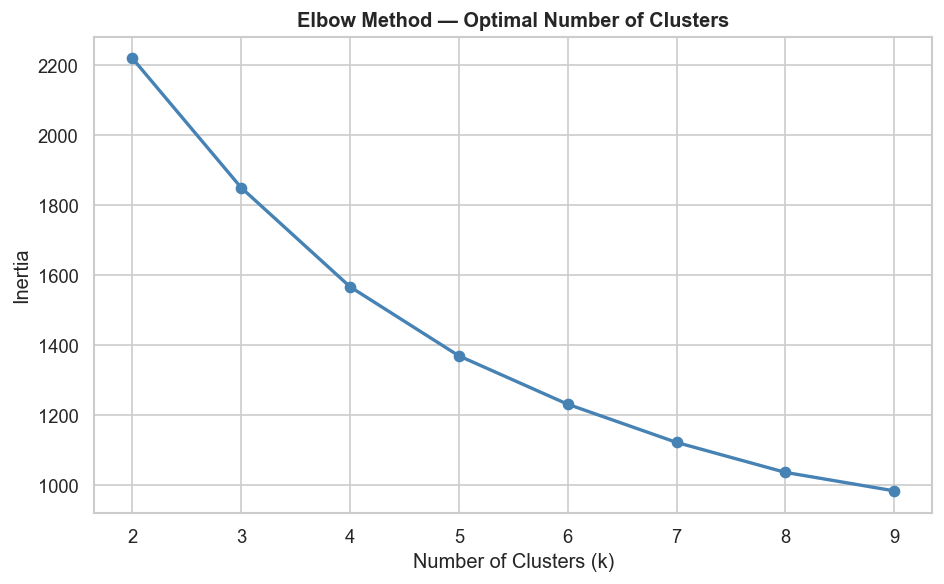

Saved: 49_elbow_method.png


In [6]:
# Cluster locations by weather profile
cluster_features = ['latitude', 'longitude', 'avg_temp',
                     'avg_humidity', 'avg_wind', 'avg_pm25']

cluster_data = location_df[cluster_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_data)

# Find optimal k with elbow method
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Optimal Number of Clusters',
             fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '49_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 49_elbow_method.png")

In [7]:
# Apply K-Means with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_data = cluster_data.copy()
cluster_data['cluster'] = kmeans.fit_predict(X_scaled)
location_df_clustered = location_df.copy()
location_df_clustered = location_df_clustered.dropna(
    subset=cluster_features
).copy()
location_df_clustered['cluster'] = cluster_data['cluster'].values

# Cluster profiles
cluster_profiles = location_df_clustered.groupby('cluster')[
    ['avg_temp', 'avg_humidity', 'avg_wind', 'avg_pm25']
].mean().round(2)
cluster_profiles.index = [f'Cluster {i}' for i in cluster_profiles.index]

print("Cluster Profiles:")
print(cluster_profiles.to_string())

Cluster Profiles:
           avg_temp  avg_humidity  avg_wind  avg_pm25
Cluster 0     27.85         39.37     15.12     12.39
Cluster 1     28.17         55.89     13.60     39.71
Cluster 2     13.00         70.65     13.06     13.44
Cluster 3     25.62         73.17     14.58      9.23
Cluster 4     23.20         79.97     10.65     13.30


In [8]:
# Plot clusters on world map
fig = px.scatter_geo(
    location_df_clustered,
    lat='latitude',
    lon='longitude',
    color='cluster',
    hover_name='location_name',
    hover_data={'country': True, 'avg_temp': ':.1f',
                'avg_humidity': ':.1f', 'cluster': True,
                'latitude': False, 'longitude': False},
    title='Weather Clusters — K-Means (k=5)',
    color_continuous_scale='Viridis'
)
fig.update_layout(
    title_font_size=16,
    geo=dict(showframe=False, showcoastlines=True,
             showland=True, landcolor='lightgray')
)
fig.write_html(str(FIGURES_DIR / '50_weather_clusters_map.html'))
fig.show()
print("Saved: 50_weather_clusters_map.html")

Saved: 50_weather_clusters_map.html


## 6. Temperature vs Latitude (Geographical Pattern)

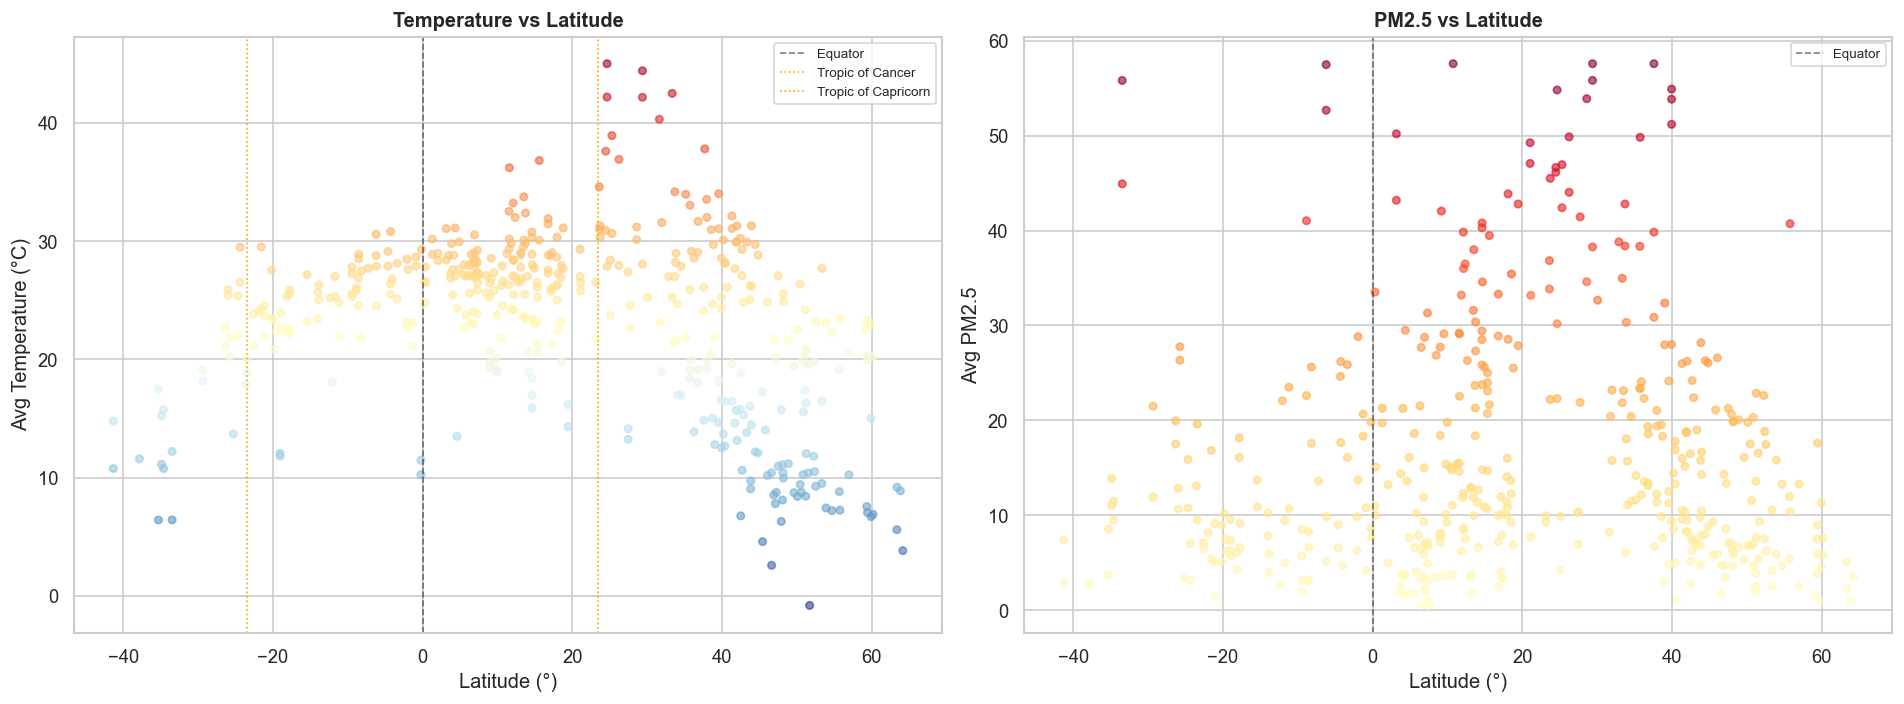

Saved: 51_temp_pm25_vs_latitude.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temperature vs Latitude
axes[0].scatter(location_df['latitude'], location_df['avg_temp'],
                c=location_df['avg_temp'], cmap='RdYlBu_r',
                alpha=0.6, s=20)
axes[0].set_title('Temperature vs Latitude', fontweight='bold')
axes[0].set_xlabel('Latitude (°)')
axes[0].set_ylabel('Avg Temperature (°C)')
axes[0].axvline(0, color='black', linestyle='--',
                linewidth=1, alpha=0.5, label='Equator')
axes[0].axvline(23.5, color='orange', linestyle=':',
                linewidth=1, label='Tropic of Cancer')
axes[0].axvline(-23.5, color='orange', linestyle=':',
                linewidth=1, label='Tropic of Capricorn')
axes[0].legend(fontsize=8)

# PM2.5 vs Latitude
axes[1].scatter(location_df['latitude'], location_df['avg_pm25'],
                c=location_df['avg_pm25'], cmap='YlOrRd',
                alpha=0.6, s=20)
axes[1].set_title('PM2.5 vs Latitude', fontweight='bold')
axes[1].set_xlabel('Latitude (°)')
axes[1].set_ylabel('Avg PM2.5')
axes[1].axvline(0, color='black', linestyle='--',
                linewidth=1, alpha=0.5, label='Equator')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '51_temp_pm25_vs_latitude.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 51_temp_pm25_vs_latitude.png")